# Long-range CNOT gate teleprotation using dynamic Cirutis

## Step-1 : Map the problem to the circuits and operations

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr

In [14]:
def get_dynamic_CNOT_circuit(num_qubit) ->QuantumCircuit:
    """
    (1) 1D chain of nearest neibghours
    (2) oth qubit is the controll , last qubit is target 
    (3) The Controll quibit starts in the + state
    """

    num_ancilla = num_qubit -2 
    num_ancilla_pair = int(num_ancilla / 2)

    qr = QuantumRegister(num_qubit)
    cr1 = ClassicalRegister(num_ancilla_pair , name= "cr1") # this is parity controlled X gate
    cr2 = ClassicalRegister(num_ancilla - num_ancilla_pair , name="cr2") # The pairity Controll Z Gate
    cr3 = ClassicalRegister(2 , name ='cr3') # For the Final mesurements on the controll and target Qubit
    qc = QuantumCircuit(qr , cr1 , cr2 , cr3)

    # Initialize the Control qubit

    qc.h(0)
    qc.barrier()
    # Entangle the controll qubit and the first Ancilla qubit

    qc.cx(0,1)
    
    for i in range(num_ancilla_pair):
        qc.h(2 + 2*i)
        qc.cx(2 +2*i , 2+2*i +1)

    # prepare the Bell gates pair on the staggered ancila and data qubits 

    for i in range(num_ancilla_pair +1):
        qc.cx(1 + 2 * i , 1 + 2*i + 1)

    for i in range(1 , num_ancilla_pair +2):
        qc.h(2*i - 1 )
    
    # Mesurement Gate on the alternative qubits starting with the first  one
    # keep track of pairity eventual conditional Z gates ! 

    for i in range(1 ,num_ancilla_pair +2):
        qc.measure(2*i -1 , cr2[i-1])
        if i == 1:
            parity_control = expr.lift(cr2[i-1])
        else:
            parity_control  = expr.bit_xor(cr2[i-1] , parity_control)

    # Mesuarement on staggered alternating ancilla qubits starting with the second
    # keep track of the parity for the eventual conditional X gate

    for i in range(num_ancilla_pair):
        qc.measure(2*i+1 , cr1[i])

        if i == 0:
            parity_target = expr.lift(cr1[i])
        else :
            parity_target = expr.bit_xor(cr1[i] , parity_target)

    with qc.if_test(parity_control):
        qc.z(0)
    
    with qc.if_test(parity_target):
        qc.x(-1)

    # Final Bell-pair measurements
    qc.measure(0, cr3[0])
    qc.measure(num_qubit - 1, cr3[1])

    return qc

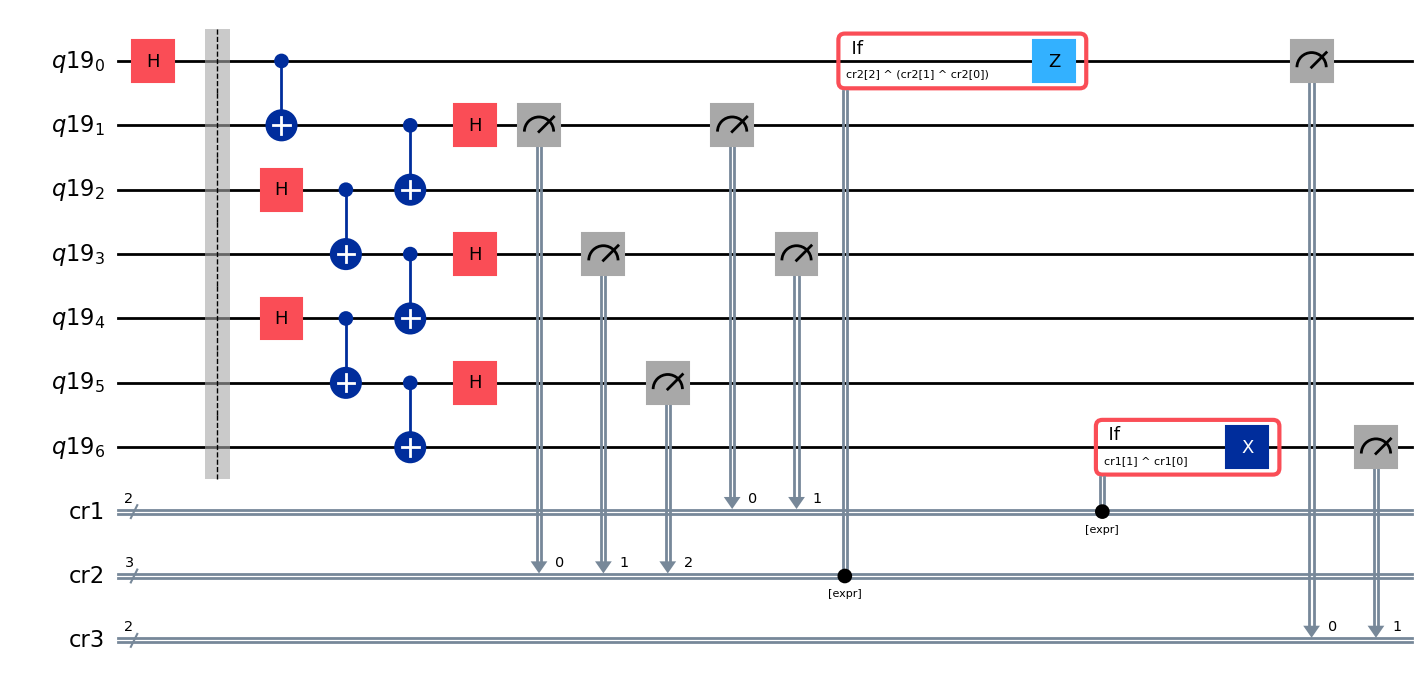

In [15]:
qc = get_dynamic_CNOT_circuit(num_qubit=7)
qc.draw(output='mpl')

In [16]:
max_num_qubit = 41
qc_list = []
num_qubit_list = list(range(7 , max_num_qubit +1 , 2))

for num_qubit in num_qubit_list:
    qc_list.append(get_dynamic_CNOT_circuit(num_qubit=num_qubit))
    

## Step-2 : optimize the Problem for the quantum execution

In [17]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService


backend_name ='ibm_fez'
service = QiskitRuntimeService()
backend = service.backend(backend_name)
pm = generate_preset_pass_manager(optimization_level=1 , backend=backend)

qc_traspile_list = pm.run(qc_list)

qiskit_runtime_service.__init__:WARNING:2026-05-25 19:45:28,619: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-25 19:45:28,619: Using instance: open-instance, plan: open


## Step-3 : Execute the Circuit

In [18]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(backend)
job = sampler.run(qc_traspile_list)
print(job.job_id())

d8a5j1is46sc73fbe1hg


## Step-4 : Post Processing and plotting

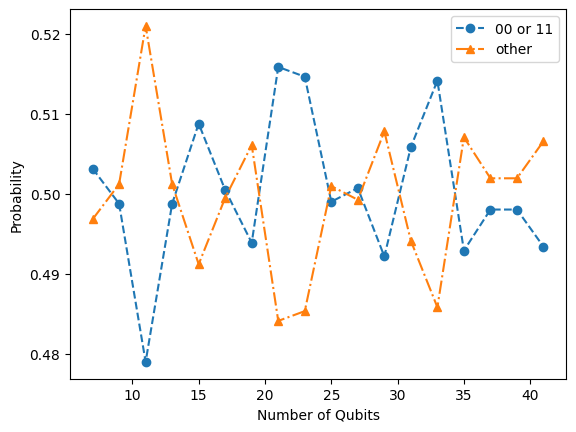

In [19]:
import matplotlib.pyplot as plt

job_id = 'd8a5j1is46sc73fbe1hg'
job = service.job(job_id=job_id)
result = job.result()

list_Bell = []
list_other = []

for i in range(len(qc_list)):

    data = result[i].data

    counts = data.cr3.get_counts()

    total_counts = sum(counts.values())

    prob_Bell = (
        counts.get('00', 0) +
        counts.get('11', 0)
    ) / total_counts

    list_Bell.append(prob_Bell)
    list_other.append(1 - prob_Bell)

plt.plot(num_qubit_list, list_Bell, '--o', label='00 or 11')
plt.plot(num_qubit_list, list_other, '-.^', label='other')

plt.xlabel("Number of Qubits")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [20]:
print(counts)

{'00': 1326, '01': 712, '10': 1363, '11': 695}
